<a href="https://colab.research.google.com/github/shrivisha/BDML-LAB-EXPMENTS/blob/main/Exp%20No%3A%208%20MODEL%20EVALUATION%20AND%20IMPROVEMENT%3A%20HYPERPARAMETER%20TUNING%20WITH%20GRID%20SEARCH%20AND%20CROSS-VALIDATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
241501202 SHRIVISHAL.SV

PART 1: HYPERPARAMETER TUNING WITH GRID SEARCH

[INFO] Dataset Features (X) shape : (150, 4)
[INFO] Dataset Labels   (y) shape : (150,)
[INFO] Feature Names              : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[INFO] Target Names               : ['setosa' 'versicolor' 'virginica']

[INFO] First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

[INFO] Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \


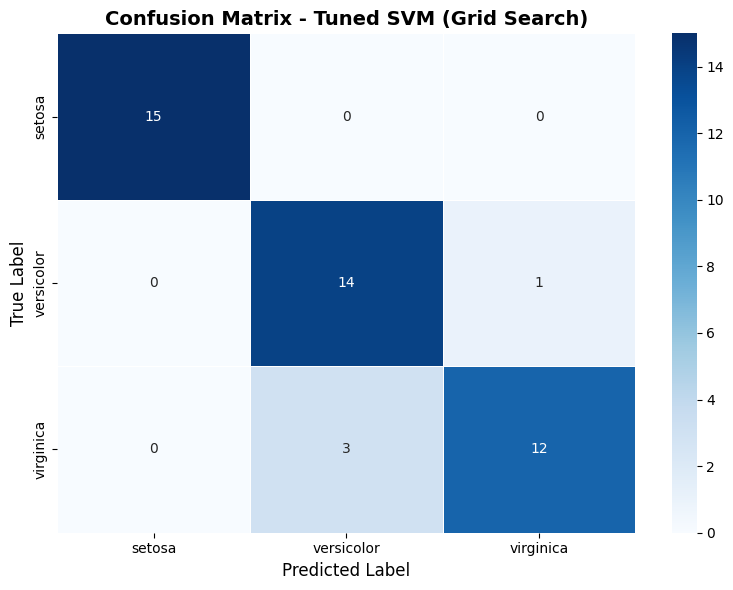

[INFO] Confusion matrix saved as 'confusion_matrix_tuned.png'

----------------------------------------------------------------------
TOP 10 GRID SEARCH RESULTS (sorted by rank)
----------------------------------------------------------------------
 param_C  param_gamma param_kernel  mean_test_score  std_test_score  rank_test_score
     1.0        0.100          rbf         0.980952        0.023328                1
   100.0        0.100       linear         0.980952        0.023328                1
   100.0        0.001       linear         0.980952        0.023328                1
   100.0        0.010       linear         0.980952        0.023328                1
   100.0        1.000       linear         0.980952        0.023328                1
     0.1        1.000       linear         0.971429        0.038095                6
     0.1        0.001       linear         0.971429        0.038095                6
     0.1        0.100       linear         0.971429        0.038095    

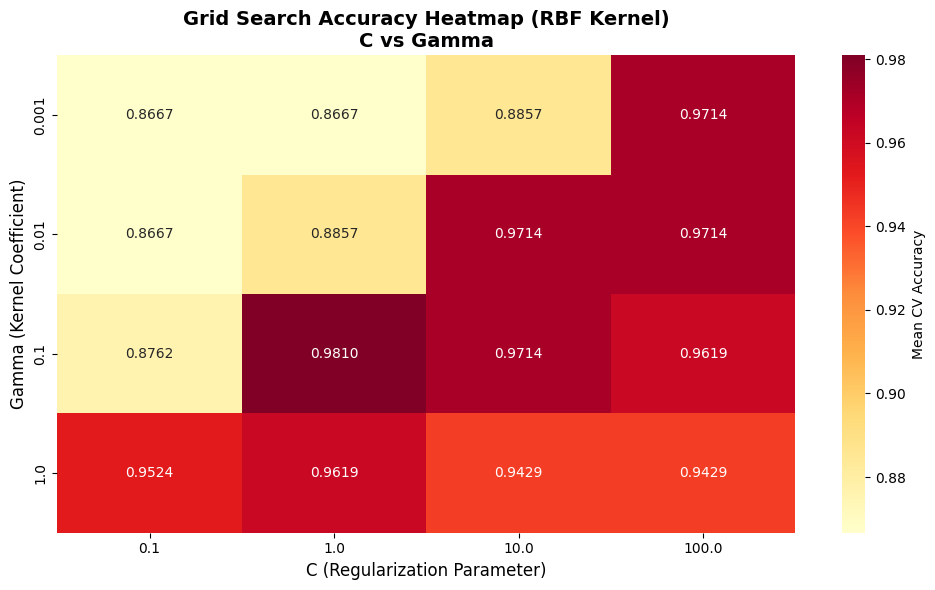

[INFO] Grid search heatmap saved as 'grid_search_heatmap.png'

PART 2: CROSS-VALIDATION TECHNIQUES (k-Fold)

[INFO] Model for CV demonstration: SVC(C=10, gamma=0.1, random_state=42)

[INFO] K-Fold Configuration:
       Number of folds  : 5
       Shuffle          : True
       Random State     : 42

------------------------------------------------------------
MANUAL K-FOLD CROSS-VALIDATION DEMONSTRATION
------------------------------------------------------------
  Fold 1: Train= 84 samples | Val= 21 samples | Accuracy=1.0000 (100.00%)
  Fold 2: Train= 84 samples | Val= 21 samples | Accuracy=0.9524 (95.24%)
  Fold 3: Train= 84 samples | Val= 21 samples | Accuracy=0.9524 (95.24%)
  Fold 4: Train= 84 samples | Val= 21 samples | Accuracy=0.9524 (95.24%)
  Fold 5: Train= 84 samples | Val= 21 samples | Accuracy=1.0000 (100.00%)

  Mean Accuracy : 0.9714 ± 0.0233

------------------------------------------------------------
AUTOMATED CROSS-VALIDATION USING cross_val_score
-------------------

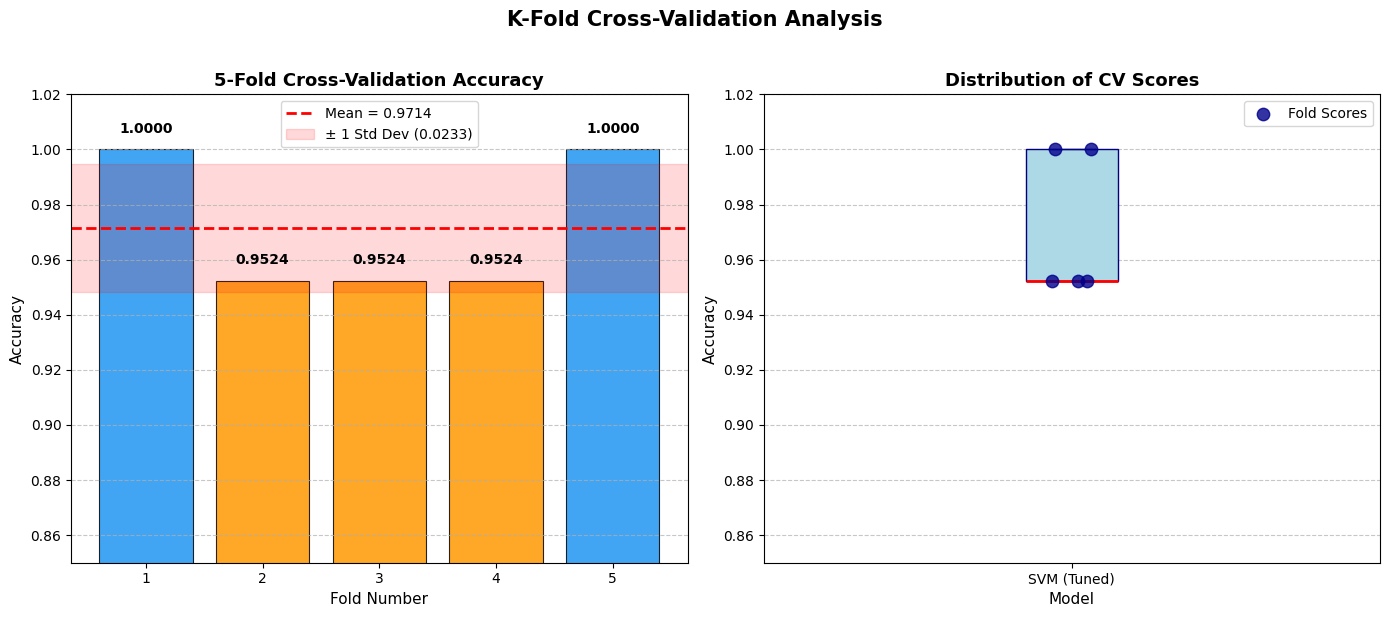

[INFO] CV results plot saved as 'cross_validation_results.png'

------------------------------------------------------------
COMPARISON OF DIFFERENT k VALUES IN k-FOLD CV
------------------------------------------------------------
  k= 2 folds → Mean=0.9523, Std=0.0100
  k= 3 folds → Mean=0.9524, Std=0.0269
  k= 5 folds → Mean=0.9714, Std=0.0233
  k=10 folds → Mean=0.9718, Std=0.0431
  k=15 folds → Mean=0.9714, Std=0.0571
  k=20 folds → Mean=0.9717, Std=0.0677


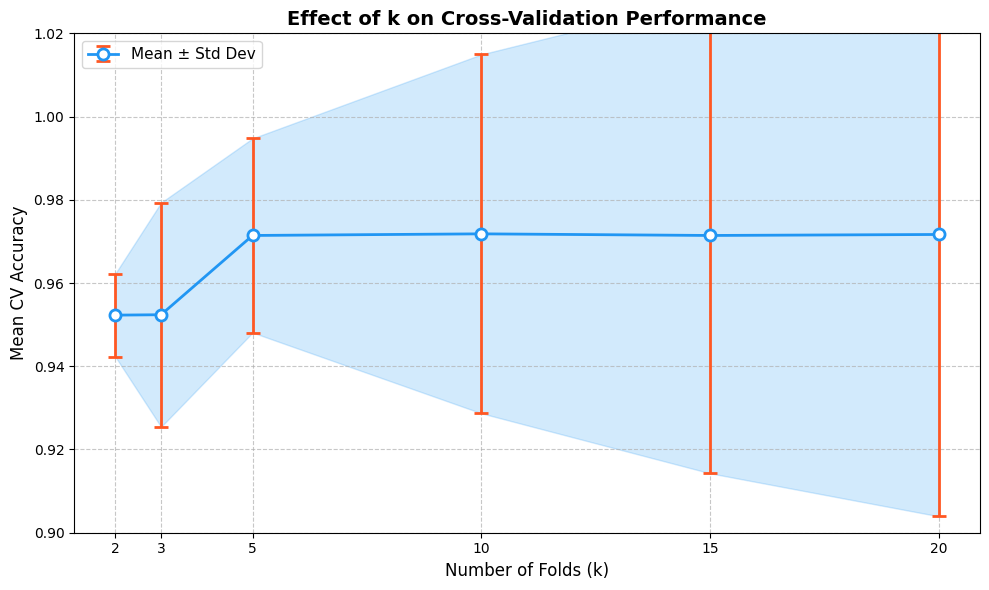

[INFO] k-fold comparison plot saved as 'k_fold_comparison.png'

FINAL SUMMARY

  [Grid Search Results]
    Best Parameters      : {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
    Best CV Accuracy     : 0.9810
    Test Set Accuracy    : 0.9111

  [Cross-Validation Results (5-Fold)]
    Fold Scores          : [1.     0.9524 0.9524 0.9524 1.    ]
    Mean Accuracy        : 0.9714
    Std Deviation        : 0.0233

  [Key Insights]
    1. Grid Search found optimal hyperparameters automatically
    2. 5-fold CV provides robust performance estimate
    3. Low std dev (0.0233) indicates stable model
    4. Test accuracy aligns with CV accuracy → no overfitting

[INFO] Why Cross-Validation is Important:
   1. More Reliable Estimate: Reduces bias from single train-test split
   2. Better Generalization: All data points used for validation
   3. Overfitting Detection: High variance across folds signals overfitting
   4. Efficient Data Usage: Every sample used for both training & validation
   5. Mode

In [ ]:
# ============================================================
# EXPERIMENT 8: MODEL EVALUATION AND IMPROVEMENT
# Hyperparameter Tuning with Grid Search and Cross-Validation
# ============================================================

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, KFold,
                                      cross_val_score, GridSearchCV)
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import StandardScaler

# ============================================================
# PART 1: HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================
print("=" * 60)
print("PART 1: HYPERPARAMETER TUNING WITH GRID SEARCH")
print("=" * 60)

# ----------------------------------------------------------
# STEP 1: Load and Explore the Iris Dataset
# ----------------------------------------------------------
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

print(f"\n[INFO] Dataset Features (X) shape : {X.shape}")
print(f"[INFO] Dataset Labels   (y) shape : {y.shape}")
print(f"[INFO] Feature Names              : {feature_names}")
print(f"[INFO] Target Names               : {target_names}")

# Basic statistics
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
print("\n[INFO] First 5 rows of dataset:")
print(df.head())
print("\n[INFO] Dataset Statistics:")
print(df.describe())

# ----------------------------------------------------------
# STEP 2: Split Data into Training and Testing Sets
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 70% train, 30% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"\n[INFO] Training set size : {X_train.shape[0]} samples")
print(f"[INFO] Test set size     : {X_test.shape[0]} samples")


print("\n[INFO] Class distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(target_names, counts):
    print(f"       {cls}: {cnt} samples")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform only

print("\n[INFO] Feature standardization completed.")
print(f"       Training mean (after scaling): "
      f"{X_train_scaled.mean(axis=0).round(4)}")
print(f"       Training std  (after scaling): "
      f"{X_train_scaled.std(axis=0).round(4)}")


param_grid = {
    'C'      : [0.1, 1, 10, 100],           # 4 values
    'gamma'  : [1, 0.1, 0.01, 0.001],       # 4 values
    'kernel' : ['rbf', 'linear']            # 2 values
}
# Total combinations = 4 × 4 × 2 = 32 combinations
# With 5-fold CV → 32 × 5 = 160 model fits

print("\n[INFO] Hyperparameter grid defined:")
print("-" * 40)
for param, values in param_grid.items():
    print(f"  {param:8s} : {values}")
print(f"\n  Total combinations : "
      f"{len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}")
print(f"  With 5-fold CV     : "
      f"{len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel']) * 5}"
      f" model fits")

# ----------------------------------------------------------
# STEP 5: Perform Grid Search with Cross-Validation
# ----------------------------------------------------------
grid_search = GridSearchCV(
    estimator  = SVC(),          # Base model
    param_grid = param_grid,     # Hyperparameter grid
    cv         = 5,              # 5-fold cross-validation
    scoring    = 'accuracy',     # Evaluation metric
    verbose    = 2,              # Show progress
    n_jobs     = -1,             # Use all CPU cores
    return_train_score = True    # Also record training scores
)

print("\n[INFO] Starting Grid Search with 5-fold Cross-Validation...")
print("-" * 60)
grid_search.fit(X_train_scaled, y_train)
print("\n[INFO] Grid Search completed successfully!")

# ----------------------------------------------------------
# STEP 6: Extract Best Parameters and Score
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("GRID SEARCH RESULTS")
print("=" * 60)
print(f"Best Hyperparameters Found  : {grid_search.best_params_}")
print(f"Best CV Accuracy Score      : {grid_search.best_score_:.4f} "
      f"({grid_search.best_score_*100:.2f}%)")
print(f"Best Estimator              : {grid_search.best_estimator_}")

# ----------------------------------------------------------
# STEP 7: Evaluate Best Model on Test Set
# ----------------------------------------------------------
best_model    = grid_search.best_estimator_
y_pred_tuned  = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"\n[RESULT] Test Set Accuracy (Tuned Model): "
      f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

#
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT - Tuned SVM Model")
print("-" * 60)
print(classification_report(y_test, y_pred_tuned,
                              target_names=target_names))


cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tuned,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = target_names,
    yticklabels = target_names,
    linewidths  = 0.5
)
plt.title('Confusion Matrix - Tuned SVM (Grid Search)',
           fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] Confusion matrix saved as 'confusion_matrix_tuned.png'")

results_df = pd.DataFrame(grid_search.cv_results_)

print("\n" + "-" * 70)
print("TOP 10 GRID SEARCH RESULTS (sorted by rank)")
print("-" * 70)
top_results = results_df[
    ['param_C', 'param_gamma', 'param_kernel',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values(by='rank_test_score').head(10)
print(top_results.to_string(index=False))



rbf_results = results_df[results_df['param_kernel'] == 'rbf'].copy()
rbf_results['param_C']     = rbf_results['param_C'].astype(float)
rbf_results['param_gamma'] = rbf_results['param_gamma'].astype(float)

pivot_table = rbf_results.pivot_table(
    values = 'mean_test_score',
    index  = 'param_gamma',
    columns = 'param_C'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_table,
    annot    = True,
    fmt      = '.4f',
    cmap     = 'YlOrRd',
    cbar_kws = {'label': 'Mean CV Accuracy'}
)
plt.title('Grid Search Accuracy Heatmap (RBF Kernel)\nC vs Gamma',
           fontsize=14, fontweight='bold')
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.ylabel('Gamma (Kernel Coefficient)', fontsize=12)
plt.tight_layout()
plt.savefig('grid_search_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] Grid search heatmap saved as 'grid_search_heatmap.png'")


print("\n" + "=" * 60)
print("PART 2: CROSS-VALIDATION TECHNIQUES (k-Fold)")
print("=" * 60)


model_cv = SVC(C=10, gamma=0.1, kernel='rbf', random_state=42)
print(f"\n[INFO] Model for CV demonstration: {model_cv}")


k_folds = 5
kf = KFold(
    n_splits     = k_folds,
    shuffle      = True,
    random_state = 42
)

print(f"\n[INFO] K-Fold Configuration:")
print(f"       Number of folds  : {k_folds}")
print(f"       Shuffle          : True")
print(f"       Random State     : 42")


print("\n" + "-" * 60)
print("MANUAL K-FOLD CROSS-VALIDATION DEMONSTRATION")
print("-" * 60)

fold_scores      = []
fold_train_sizes = []
fold_val_sizes   = []

for fold_num, (train_idx, val_idx) in enumerate(
    kf.split(X_train_scaled), 1
):

    X_fold_train = X_train_scaled[train_idx]
    X_fold_val   = X_train_scaled[val_idx]
    y_fold_train = y_train[train_idx]
    y_fold_val   = y_train[val_idx]


    model_cv.fit(X_fold_train, y_fold_train)


    fold_acc = model_cv.score(X_fold_val, y_fold_val)
    fold_scores.append(fold_acc)
    fold_train_sizes.append(len(train_idx))
    fold_val_sizes.append(len(val_idx))

    print(f"  Fold {fold_num}: "
          f"Train={len(train_idx):3d} samples | "
          f"Val={len(val_idx):3d} samples | "
          f"Accuracy={fold_acc:.4f} ({fold_acc*100:.2f}%)")

print(f"\n  Mean Accuracy : {np.mean(fold_scores):.4f} ± "
      f"{np.std(fold_scores):.4f}")


print("\n" + "-" * 60)
print("AUTOMATED CROSS-VALIDATION USING cross_val_score")
print("-" * 60)

cv_scores = cross_val_score(
    estimator = model_cv,
    X         = X_train_scaled,
    y         = y_train,
    cv        = kf,
    scoring   = 'accuracy'
)

print(f"\n  CV Scores per fold  : {np.round(cv_scores, 4)}")
print(f"  Mean CV Accuracy    : {np.mean(cv_scores):.4f} "
      f"({np.mean(cv_scores)*100:.2f}%)")
print(f"  Std Dev             : {np.std(cv_scores):.4f}")
print(f"  Min Score           : {np.min(cv_scores):.4f}")
print(f"  Max Score           : {np.max(cv_scores):.4f}")
print(f"  95% Confidence Int. : ({np.mean(cv_scores) - 2*np.std(cv_scores):.4f}, "
      f"{np.mean(cv_scores) + 2*np.std(cv_scores):.4f})")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


colors = ['#2196F3' if s >= np.mean(cv_scores) else '#FF9800'
          for s in cv_scores]
bars = axes[0].bar(
    range(1, k_folds + 1),
    cv_scores,
    color  = colors,
    edgecolor = 'black',
    linewidth = 0.8,
    alpha  = 0.85
)


for bar, score in zip(bars, cv_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.4f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )


axes[0].axhline(
    y         = np.mean(cv_scores),
    color     = 'red',
    linestyle = '--',
    linewidth = 2,
    label     = f'Mean = {np.mean(cv_scores):.4f}'
)

axes[0].axhspan(
    np.mean(cv_scores) - np.std(cv_scores),
    np.mean(cv_scores) + np.std(cv_scores),
    alpha = 0.15, color = 'red',
    label = f'± 1 Std Dev ({np.std(cv_scores):.4f})'
)

axes[0].set_title(f'{k_folds}-Fold Cross-Validation Accuracy',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fold Number', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_ylim(0.85, 1.02)
axes[0].set_xticks(range(1, k_folds + 1))
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


axes[1].boxplot(cv_scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'))
x_jitter = np.random.normal(1, 0.02, len(cv_scores))
axes[1].scatter(x_jitter, cv_scores, color='darkblue',
                 zorder=5, s=80, alpha=0.8, label='Fold Scores')

axes[1].set_title('Distribution of CV Scores',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_ylim(0.85, 1.02)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['SVM (Tuned)'])
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('K-Fold Cross-Validation Analysis',
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] CV results plot saved as 'cross_validation_results.png'")
print("\n" + "-" * 60)
print("COMPARISON OF DIFFERENT k VALUES IN k-FOLD CV")
print("-" * 60)

k_values    = [2, 3, 5, 10, 15, 20]
mean_scores = []
std_scores  = []

for k in k_values:
    kf_temp = KFold(n_splits=k, shuffle=True, random_state=42)
    scores  = cross_val_score(model_cv, X_train_scaled, y_train,
                               cv=kf_temp, scoring='accuracy')
    mean_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))
    print(f"  k={k:2d} folds → Mean={np.mean(scores):.4f}, "
          f"Std={np.std(scores):.4f}")

# Plot k comparison
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_scores, yerr=std_scores,
             fmt='o-', capsize=5, capthick=2,
             color='#2196F3', ecolor='#FF5722',
             linewidth=2, markersize=8, markerfacecolor='white',
             markeredgewidth=2, label='Mean ± Std Dev')
plt.fill_between(k_values,
                  [m - s for m, s in zip(mean_scores, std_scores)],
                  [m + s for m, s in zip(mean_scores, std_scores)],
                  alpha=0.2, color='#2196F3')
plt.title('Effect of k on Cross-Validation Performance',
           fontsize=14, fontweight='bold')
plt.xlabel('Number of Folds (k)', fontsize=12)
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.ylim(0.90, 1.02)
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('k_fold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[INFO] k-fold comparison plot saved as 'k_fold_comparison.png'")

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"\n  [Grid Search Results]")
print(f"    Best Parameters      : {grid_search.best_params_}")
print(f"    Best CV Accuracy     : {grid_search.best_score_:.4f}")
print(f"    Test Set Accuracy    : {test_accuracy:.4f}")

print(f"\n  [Cross-Validation Results (5-Fold)]")
print(f"    Fold Scores          : {np.round(cv_scores, 4)}")
print(f"    Mean Accuracy        : {np.mean(cv_scores):.4f}")
print(f"    Std Deviation        : {np.std(cv_scores):.4f}")

print(f"\n  [Key Insights]")
print(f"    1. Grid Search found optimal hyperparameters automatically")
print(f"    2. 5-fold CV provides robust performance estimate")
print(f"    3. Low std dev ({np.std(cv_scores):.4f}) indicates stable model")
print(f"    4. Test accuracy aligns with CV accuracy → no overfitting")

print("\n[INFO] Why Cross-Validation is Important:")
insights = [
    "1. More Reliable Estimate: Reduces bias from single train-test split",
    "2. Better Generalization: All data points used for validation",
    "3. Overfitting Detection: High variance across folds signals overfitting",
    "4. Efficient Data Usage: Every sample used for both training & validation",
    "5. Model Selection: Provides fair comparison between different models"
]
for insight in insights:
    print(f"   {insight}")

print("\n" + "=" * 60)
print("EXPERIMENT 8 COMPLETED SUCCESSFULLY")
print("=" * 60)